In [2]:
from populations import gw_obs
import populations.bbh_models as read_models
import numpy as np
from tqdm import tqdm
from sample.sample import lnlike_cont
import matplotlib.pyplot as plt 


/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
params = ['mchirp','q', 'chieff', 'z']
gw_path = "/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/GWTC-3/events"
file_path='/data/wiay/2297403c/models_reduced.hdf5'
flow_path = "/data/wiay/2297403c/amaze_model_select/AMAZE_project_resources/test_production_runs/flows_prod_tests/flow_models/"
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            100, 'posteriors', 'p_theta_jcb')

model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, use_unityweights=False, device='cpu',\
     no_bins=[5,4,4,5,4], sensitivity='midhighlatelow', flow_path=flow_path)
for chnl in channels: flow[chnl].load_model(flow_path, device='cpu')


100%|██████████| 5/5 [01:34<00:00, 18.96s/it]


cpu
cpu
cpu
cpu
cpu


In [4]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000

x = [0.1,4.8,0.8,0.05,0.01,0.05]
prob_test = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).


In [5]:
prob_test

341.1411720355256

In [8]:
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}
smallest_N=100000


prob = np.zeros((20,5))
for seed in range(5):
    np.random.seed(seed)
    observations, obsdata, p_theta, events = gw_obs.generate_observations(params, gw_path, \
                                            10, 'posteriors', 'p_theta_jcb')
    #for e, event in enumerate(obsdata):
    for i, chib in enumerate(tqdm(np.linspace(0,0.1,20))):
        x = [chib,4.8,0.8,0.05,0.01,0.05]
        prob[i,seed] = (lnlike_cont(x, obsdata, flow, submodels_dict, channels, p_theta, smallest_N))

100%|██████████| 20/20 [00:25<00:00,  1.27s/it]


Text(0, 0.5, 'normalised p(chi_b)')

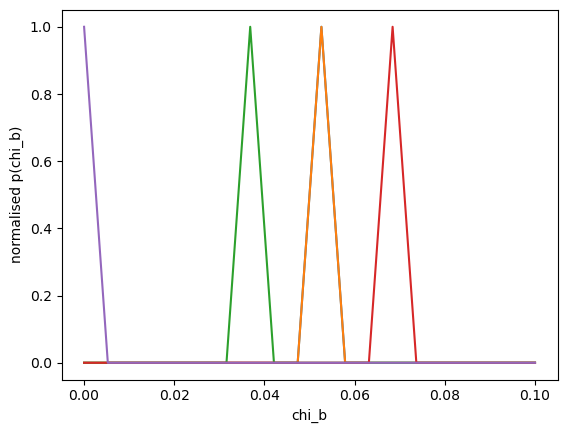

In [9]:
for seed in range(5):
    plt.plot(np.linspace(0,0.1,20), np.exp(prob[:,seed])/np.sum(np.exp(prob[:,seed])))
plt.xlabel('chi_b')
plt.ylabel('normalised p(chi_b)')